<a href="https://colab.research.google.com/github/moon14m/Pente-game/blob/main/Lab1%20Data%20mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining & Warehousing — Lab 1
## Introduction & Data Preprocessing
<br>

## Lab Overview

By the end of this lab you will be able to:

- Load a dataset into a pandas DataFrame and do a first inspection
- Detect and handle **missing values** using several strategies
- Detect and handle **duplicate records**
- Detect and handle **outliers**
- Build simple, informative **visualizations** to support the analysis

These are the core steps of the **data preprocessing** stage of any data mining or data warehousing project (recall the *Extract → Transform → Load* pipeline from the handout).

**Data Preprocessing** is the process of preparing data directly after accessing it from a data source. It typically involves cleaning, transforming, and organizing raw data so it is ready for analysis or modeling. Real-world data is almost never clean — it usually has missing values, duplicate records, and outliers, all of which we'll practice handling below.

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
%matplotlib inline

In [4]:
import urllib.request
import os

# URLs to download the required datasets
urls = {
    'student_performance.csv': 'https://raw.githubusercontent.com/youssef-attai/Data-Mining-Warehousing/main/student_performance.csv',
    'online_orders.csv': 'https://raw.githubusercontent.com/youssef-attai/Data-Mining-Warehousing/main/online_orders(1).csv'
}

for filename, url in urls.items():
    if not os.path.exists(filename):
        print(f'Downloading {filename}...')
        try:
            urllib.request.urlretrieve(url, filename)
            print(f'Successfully downloaded {filename}')
        except Exception as e:
            print(f'Failed to download {filename}: {e}')
    else:
        print(f'{filename} already exists.')

student_performance.csv already exists.
online_orders.csv already exists.


## 1. Loading & First Look at the Data

We'll work with `student_performance.csv` — a (simulated) dataset describing university students' study habits and their exam performance.

In [5]:
studentDF = pd.read_csv('student_performance.csv')
studentDF.head()

,student_id,gender,study_hours_per_week,attendance_percentage,sleep_hours,part_time_job,internet_access,previous_grade,final_score
0,1490,Female,13.8,73.4,6.4,No,Yes,69.4,63.7
1,1430,Female,15.1,66.2,6.4,No,Yes,60.9,58.7
2,1083,Male,15.0,54.6,4.6,No,Yes,61.4,73.4
3,1121,Male,13.5,NaN,7.6,No,Yes,75.8,69.4
4,1222,Male,5.6,68.0,5.5,NaN,Yes,67.1,43.2


In [ ]:
studentDF.info()

In [ ]:
studentDF.shape

In [ ]:
studentDF.describe()

Always start by getting to know your columns:

In [ ]:
column_names = studentDF.columns
print(column_names)

In [ ]:
# only if needed
# To show all columns
#pd.set_option("display.max_columns", None)

# To show all rows (if needed)
#pd.set_option("display.max_rows", None)

## 2. Dealing with Missing Values

Common strategies:
- **Omit** the rows/columns (drop)
- **Impute** a static value such as the mean, median, or mode
- Use **interpolation**

The right choice depends on *how much* is missing and *what kind* of column it is (numeric vs categorical).

In [6]:
# DF.isnull() returns True where a value is missing
studentDF.isnull()

,student_id,gender,study_hours_per_week,attendance_percentage,sleep_hours,part_time_job,internet_access,previous_grade,final_score
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
510,False,False,False,False,False,False,False,False,False
511,False,False,False,False,False,False,False,False,False
512,False,False,False,False,False,False,False,False,False
513,False,False,False,False,False,False,False,False,False


In [10]:
studentDF.isnull().sum()

,0
student_id,0
gender,0
study_hours_per_week,0
attendance_percentage,31
sleep_hours,51
part_time_job,16
internet_access,20
previous_grade,27
final_score,0


In [9]:
# another way to detect null values
studentDF.isna().sum()

,0
student_id,0
gender,0
study_hours_per_week,0
attendance_percentage,31
sleep_hours,51
part_time_job,16
internet_access,20
previous_grade,27
final_score,0


In [8]:
# percentage of missing values per column — often more useful than the raw count
(studentDF.isnull().mean() * 100).round(2)

,0
student_id,0.00
gender,0.00
study_hours_per_week,0.00
attendance_percentage,6.02
sleep_hours,9.90
part_time_job,3.11
internet_access,3.88
previous_grade,5.24
final_score,0.00


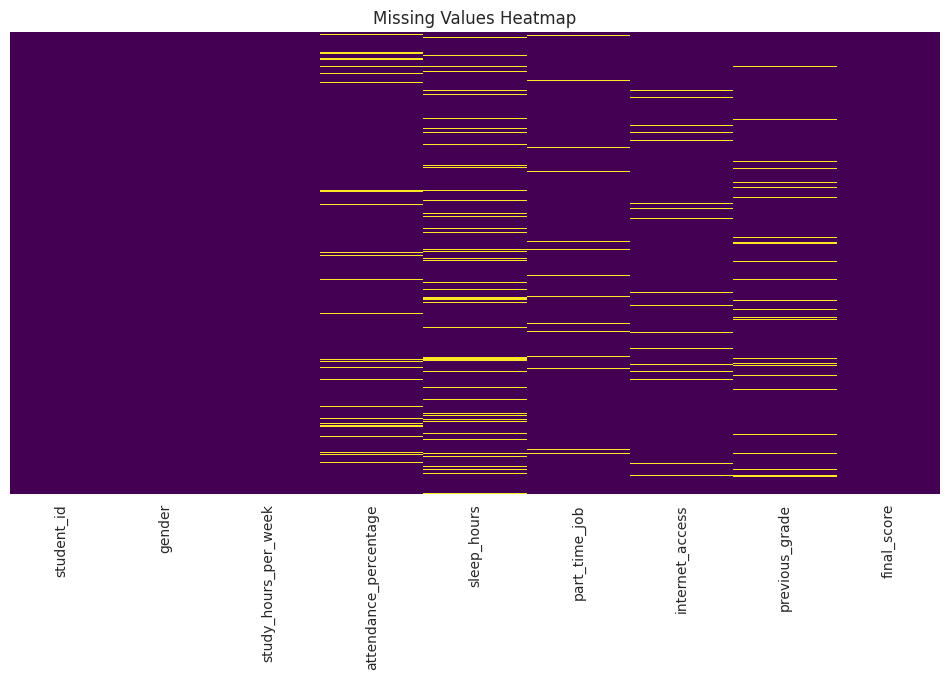

In [7]:
# Using a heatmap to visually identify where the missing values are
plt.figure(figsize=(12,6))
sns.heatmap(studentDF.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 2.1 Option A — Dropping

In [11]:
## You can easily drop rows that contain NaNs, but you may lose important data
studentDF.dropna().shape

(386, 9)

In [13]:
## Or drop a whole column if it's mostly missing
## (none of our columns are this bad, but this is how you'd do it)
# studentDF.drop(['some_column'], axis=1, inplace=True)

### 2.2 Option B — Imputing

Let's treat each column appropriately instead of dropping everything:
- `attendance_percentage`, `previous_grade` → fill with the **mean** (roughly symmetric)
- `sleep_hours` → fill with the **median** (more robust to skew/outliers)
- `part_time_job`, `internet_access` → fill with the **mode** (categorical columns)

In [20]:
studentDF_clean = studentDF.copy()

studentDF_clean['attendance_percentage'] = studentDF_clean['attendance_percentage'].fillna(
    studentDF_clean['attendance_percentage'].mean())

studentDF_clean['previous_grade'] = studentDF_clean['previous_grade'].fillna(
    studentDF_clean['previous_grade'].mean())

In [23]:
studentDF_clean['sleep_hours'] = studentDF_clean['sleep_hours'].fillna(
    studentDF_clean['sleep_hours'].median())

In [ ]:
for col in ['part_time_job', 'internet_access']:
    studentDF_clean[col] = studentDF_clean[col].fillna(studentDF_clean[col].mode()[0])

NameError: name 'studentDF_clean' is not defined

### 2.3 Option C — Interpolation (numeric, order-sensitive data)

In [24]:
# Interpolation estimates missing values from neighbouring rows —
# more meaningful for ordered/time-based data, shown here for completeness
studentDF['previous_grade'].interpolate(method='linear').isnull().sum()

np.int64(0)

In [25]:
# Confirm our cleaned dataframe has no missing values left
studentDF_clean.isnull().sum()

,0
student_id,0
gender,0
study_hours_per_week,0
attendance_percentage,0
sleep_hours,0
part_time_job,16
internet_access,20
previous_grade,0
final_score,0


## 3. Checking for Duplicates

In [26]:
studentDF_clean.duplicated().sum()

np.int64(15)

In [ ]:
studentDF_clean[studentDF_clean.duplicated()]

### Dealing with Duplicates

In [27]:
# Drop all duplicated values without keeping any copy
studentDF_clean.drop_duplicates().shape

(500, 9)

In [28]:
# Drop duplicates while keeping the LAST occurrence of each
studentDF_clean = studentDF_clean.drop_duplicates(keep='last').reset_index(drop=True)
studentDF_clean.duplicated().sum()

np.int64(0)

## 4. Checking for Outliers

### Using a Boxplot
Points that fall far outside the box (beyond the whiskers) are candidate outliers.

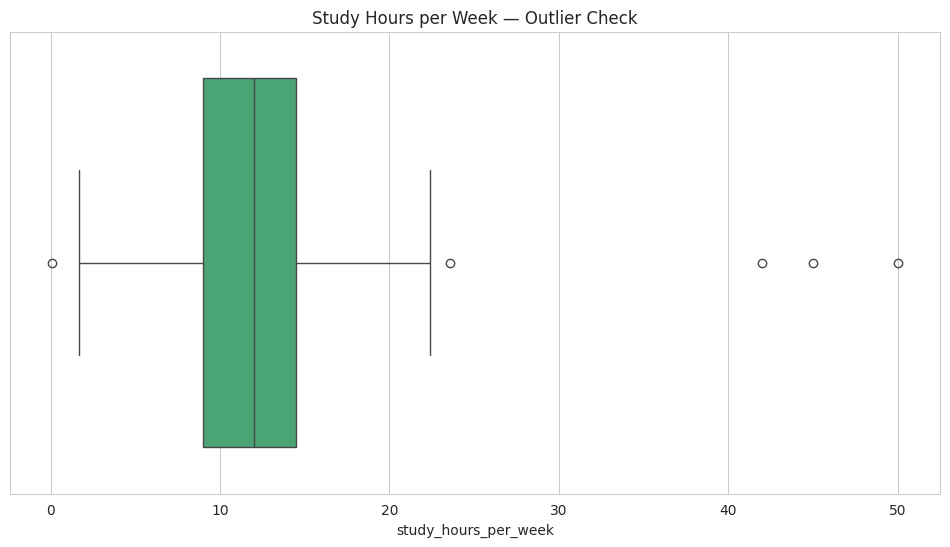

In [29]:
plt.figure(figsize=(12,6))
sns.boxplot(x='study_hours_per_week', data=studentDF_clean, color='mediumseagreen')
plt.title('Study Hours per Week — Outlier Check')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='final_score', data=studentDF_clean, color='mediumseagreen')
plt.title('Final Score — Outlier Check')
plt.show()

### Using the IQR Method

A common rule of thumb: a value is an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`, where `IQR = Q3 - Q1`.

In [30]:
def get_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

lower, upper = get_outlier_bounds(studentDF_clean['final_score'])
print(f'Valid range: {lower:.1f} to {upper:.1f}')

outliers = studentDF_clean[(studentDF_clean['final_score'] < lower) | (studentDF_clean['final_score'] > upper)]
outliers[['student_id','final_score']]

Valid range: 29.8 to 85.5


,student_id,final_score
84,1053,29.0
243,1442,150.0
352,1107,-10.0
422,1380,140.0


In [31]:
# Option 1: remove the outlier rows
studentDF_clean = studentDF_clean[
    (studentDF_clean['final_score'] >= lower) & (studentDF_clean['final_score'] <= upper)
].reset_index(drop=True)

# Option 2 (alternative, not applied here): cap/clip instead of removing
# studentDF_clean['final_score'] = studentDF_clean['final_score'].clip(lower, upper)

studentDF_clean.shape

(496, 9)

## 5. Visualization for Insight

Now that the data is clean, visualizations become much more trustworthy and useful.

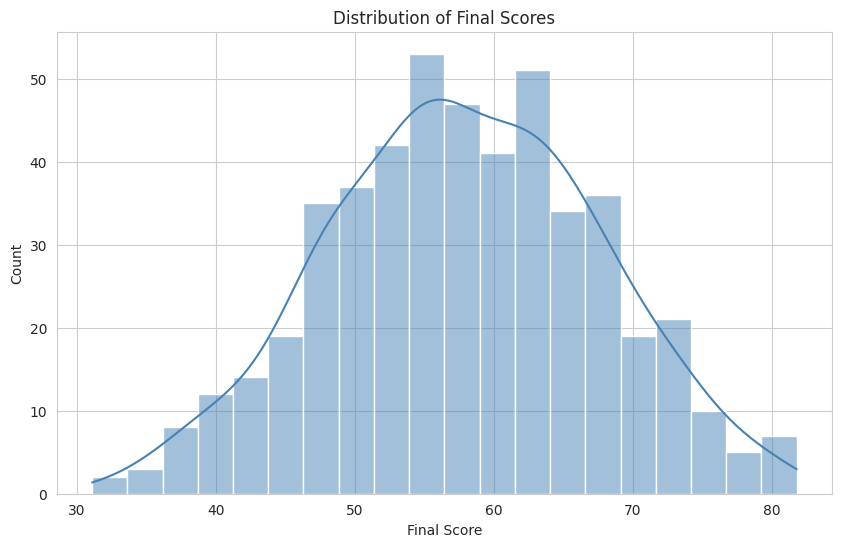

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(studentDF_clean['final_score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.show()

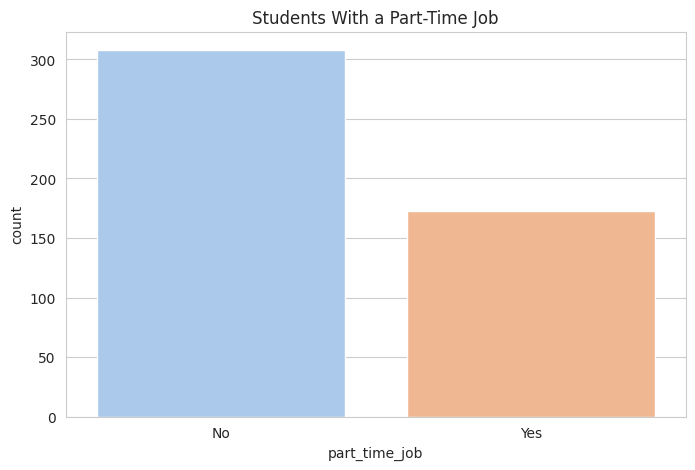

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='part_time_job', hue='part_time_job', data=studentDF_clean, palette='pastel', legend=False)
plt.title('Students With a Part-Time Job')
plt.show()

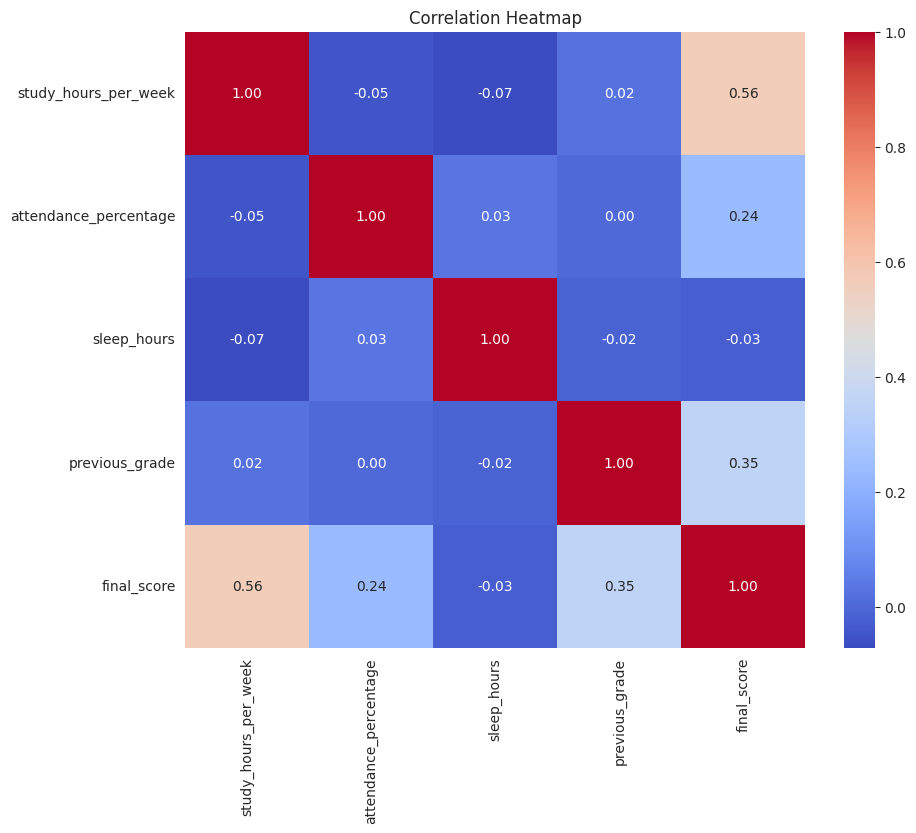

In [34]:
plt.figure(figsize=(10,8))
numeric_cols = studentDF_clean.select_dtypes(include=[np.number]).drop(columns=['student_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

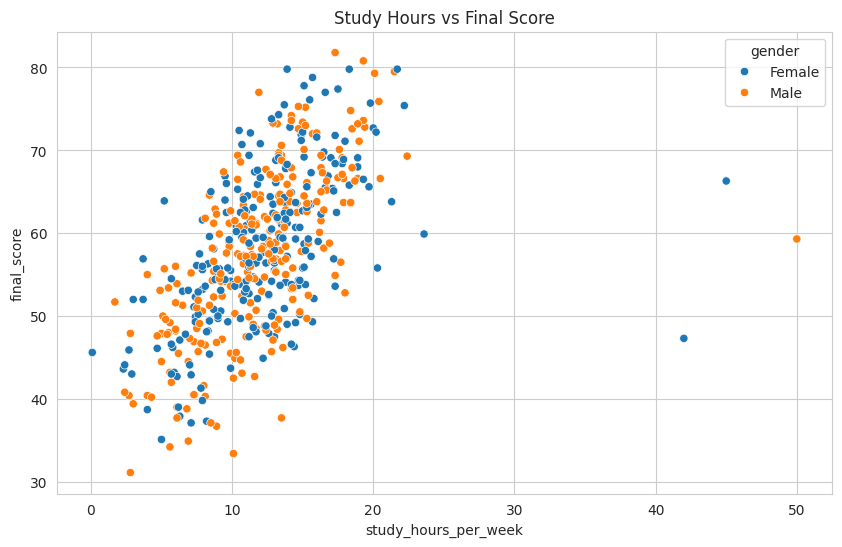

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_week', y='final_score', hue='gender', data=studentDF_clean)
plt.title('Study Hours vs Final Score')
plt.show()

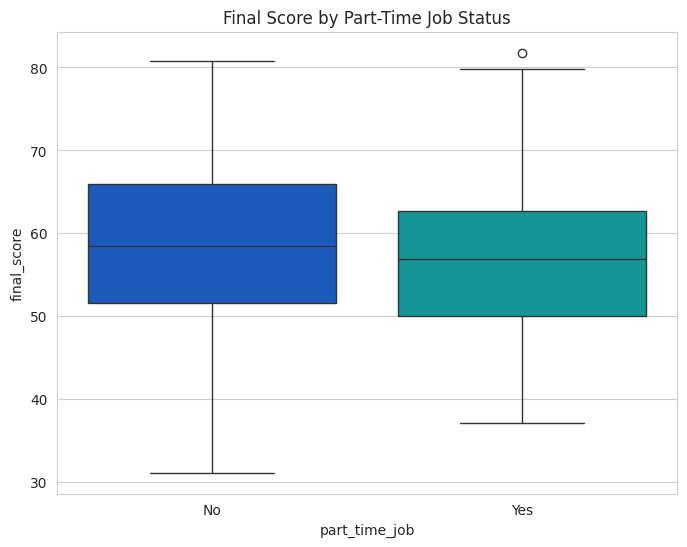

In [36]:
plt.figure(figsize=(8,6))
sns.boxplot(x='part_time_job', y='final_score', hue='part_time_job', data=studentDF_clean, palette='winter', legend=False)
plt.title('Final Score by Part-Time Job Status')
plt.show()

---
## Home Exercise

Now it's your turn! Apply everything from this lab to a **new** dataset: `online_orders.csv`, containing simulated online store orders.

Complete each cell below. Ask on the module forum or bring questions to office hours (Monday 11:00–13:00) if you get stuck.

In [39]:
ordersDF = pd.read_csv('online_orders.csv')

**1.** Show the first 5 rows of the dataframe.

In [40]:
###########Your Sol#########
ordersDF.head(5)

,order_id,category,country,unit_price,quantity,discount_pct,customer_rating,delivery_days,total_amount
0,5033,Electronics,UAE,36.84,6,15.0,3.9,9.0,187.88
1,5003,Home & Kitchen,Saudi Arabia,25.27,5,15.0,4.3,5.0,107.40
2,5281,Books,Egypt,30.44,1,10.0,3.4,1.0,27.40
3,5173,Books,Saudi Arabia,14.92,4,NaN,5.0,11.0,59.68
4,5160,Clothing,NaN,46.68,2,0.0,3.9,6.0,93.36


**2.** Print the shape of the dataframe. What does each dimension represent?

In [42]:
###########Your Sol#########
ordersDF.shape


(410, 9)

**3.** Retrieve the first three columns for rows at index 5 to 10, using both `.loc` and `.iloc`.

In [ ]:
###########Your Sol#########
# Using .loc (inclusive of start and end index values)
ordersDF.loc[5:10, ordersDF.columns[:3]]

# Using .iloc (uses positional integer indexing, where the end index is excluded)
ordersDF.iloc[5:11, :3]

**4.** Print the data types of all columns.

In [ ]:
###########Your Sol#########
ordersDF.dtypes

**5.** Print the number of missing values in each column.

In [ ]:
###########Your Sol#########
ordersDF.isnull().sum()

**6.** Drop any column that has more than **70** missing values, then print the number of nulls again.

In [ ]:
###########Your Sol#########
# Drop columns with more than 70 missing values
ordersDF = ordersDF.dropna(thresh=len(ordersDF) - 70, axis=1)

# Print the number of missing values again
ordersDF.isnull().sum()

**7.** For the remaining missing values: fill numeric columns with the median and categorical columns with the mode. Print the number of nulls again to confirm.

In [ ]:
###########Your Sol#########
# Fill numeric columns with median
numeric_cols = ordersDF.select_dtypes(include=['number']).columns
ordersDF[numeric_cols] = ordersDF[numeric_cols].fillna(ordersDF[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = ordersDF.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    ordersDF[col] = ordersDF[col].fillna(ordersDF[col].mode()[0])

# Confirm all missing values are filled
ordersDF.isnull().sum()

**8.** Print the unique values of the `country` column.

In [ ]:
###########Your Sol#########
ordersDF['country'].unique()

**9.** Print the duplicated rows, then drop duplicates while keeping the **last** occurrence.

In [ ]:
###########Your Sol#########
# Print the duplicated rows
print("Duplicated rows:")
display(ordersDF[ordersDF.duplicated()])

# Drop duplicates while keeping the last occurrence
ordersDF = ordersDF.drop_duplicates(keep='last').reset_index(drop=True)

**10.** Using a boxplot, check the `total_amount` column for outliers. Then, using the IQR method, remove any rows that are outliers.

In [ ]:
###########Your Sol#########
# 1. Boxplot to visually check for outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=ordersDF['total_amount'], color='skyblue')
plt.title('Outliers Check for Total Amount')
plt.show()

# 2. Calculate IQR bounds
Q1 = ordersDF['total_amount'].quantile(0.25)
Q3 = ordersDF['total_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter out rows that are outliers
ordersDF = ordersDF[(ordersDF['total_amount'] >= lower_bound) & (ordersDF['total_amount'] <= upper_bound)].reset_index(drop=True)

**11. (Bonus)** Create a bar chart showing the number of orders per `category`.

In [ ]:
###########Your Sol#########
plt.figure(figsize=(8, 5))
sns.countplot(data=ordersDF, x='category', palette='Set2')
plt.title('Number of Orders per Category')
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.show()